In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:17pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:17pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size="6" color="red">ch10. N차원 배열 다루기</font>
- N차원 배얄 객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [numpy](https://numpy.org)
- [numpy API Docs](https://numpy.org/doc/stable/referenece/index.html)
# 1절. 넘파이 패키지

In [3]:
import numpy as np
np.__version__ # tensorf == 2.10과 맞는 numpy 버전

'1.23.5'

In [4]:
# np.arange(from,stop, by) : from 부터 stop앞까지 by씩 증가하는정수 배열
a = np.arange(15)
print(a.shape) # 15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

# 1.1 배열속성

In [5]:
from numpy import arange
a = arange(15,  # dtype=np.int8
          ).reshape(3, 5) # 3행5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [6]:
type(a) # a타입 변수

numpy.ndarray

In [7]:
a.dtype # a배열의 요소 (item)들의 type

dtype('int32')

In [8]:
a.dtype.name

'int32'

In [9]:
a.itemsize # 한 요소(item) 의 bytesize

4

In [10]:
a.ndim # 축수(차원수)

2

In [11]:
a.size # 배열 요소의 갯수

15

In [12]:
a.shape # 배열 구조 (1차원 15열)

(3, 5)

In [13]:
print('shape 조정전 a:\n', a)
a.shape = (5, 3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경


In [14]:
# 배열 요소의 타입변경(X)
a = np.arange(12). reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [15]:
a.size # 요소갯수

12

In [16]:
a.dtype 

dtype('int32')

In [17]:
a.itemsize # 요소의 byte수

4

In [18]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [19]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [20]:
a.size # 요소수

6

In [21]:
# 배열 요소의 타입변경(O)
a = arange(15).reshape(5, 3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [22]:
a = a.astype(np.int64) # 출력 o -> a 가 바뀌지 않음. 출력X ->a바뀜

In [23]:
a.dtype

dtype('int64')

In [24]:
a.itemsize

8

In [25]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [26]:
a.ravel() # flaten된 배열을 return 

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [27]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

# 1.3 배열저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [28]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [29]:
%%time
import pickle
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)

CPU times: total: 0 ns
Wall time: 997 µs


In [30]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

CPU times: total: 0 ns
Wall time: 1 ms


In [31]:
# a == (파일저장) ==> 피클파일(269B) == (load) ==> loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [32]:
%%time
np.save('data/ch11.npy', a) # 넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 1.01 ms


In [33]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 945 µs


In [34]:
# a == (저장) ==> npy(248B) == (load) ==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이 배열
- array()함수를 이용한 다른 파이썬 데이터 구조(list, tup)를 배열로 변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.....
- 랜덤값을 갖는 배열 생성 함수 .....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F)
type 예 int16, int32, float16, float32, float64, .....

In [35]:
a = np.array([2, 14, 6],
            # dtype=np.int16
            ) # 정수의 기본타입은 int32/실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [36]:
a[0], a[1], a[2]

(2, 14, 6)

In [37]:
for item in a:
    print(item, end='\t')

2	14	6	

In [38]:
b = np.array([[1.5,2.3],   # 동일자료형의집합으로 배열 생성 : 정수>실수>문자
             [4, 5]])      # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [39]:
b.dtype

dtype('float64')

In [40]:
l = [[1.5, 2.3], [4, 5]]
l[0][1]

2.3

In [41]:
b[0,1] # 2차원 [axis0=행, axis1=열] cf. 1차원[axis0=열]

2.3

In [42]:
a = np.array([[1.5, 2.3],
             [4,5]], dtype=np.float32)
            # dtype="float32")
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [43]:
a.dtype

dtype('float32')

In [44]:
# a의 배열 구조 변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [45]:
# a의 dtype(요소의 타입) 변경
# a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [46]:
l = [[1.5, 2.3], 
     [4,5]]
for row in l:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4 5 


In [47]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {l[i][j]}", end='\t')
    print()

0행0열 : 1.5	0행1열 : 2.3	
1행0열 : 4	1행1열 : 5	


In [48]:
for row in a:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4.0 5.0 


In [49]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
        #print(f"{i}행{j}열 : {a[i][j]}", end='\t')
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소숫점이하가 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [50]:
print(b[0,-1]) # 인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

2.3


In [51]:
# 슬라이싱 from:stop:by : from부터 stop전까지 by씩 전진. 인덱싱은 음수
b[0:, 1:10] # 0~끝행, 1열부터10전열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [52]:
b[0, 1:3] # 0행,1열부터3열전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

In [53]:
b = np.array([[1, 2, 3],
              [6, 7, 8]])
# 모든 행의 마지막 열만 추출
b[:, -1:], b[:, -1]

(array([[3],
        [8]]),
 array([3, 8]))

In [54]:
# 모든 행의 마지막 열을 제외한 부분 추출
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [55]:
# 스칼라 변수
a = 10  # 원본
b = a   # 복제본
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=2457648562704, b주소=2457648562704
a=10, b=-1, a주소=2457648562704, b주소=2457648562352


In [56]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False) # d = c 동일 #할당
print("c=", c, sep="\n")
print("d=", c, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", d, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2457764423952 2457764423952
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2457764423952 2457764423952


In [57]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=True) # d = c.copy()와 동일 #깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2457764424336 2457764424624
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2457764424336 2457764424624


In [58]:
# copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False,    dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2457764420400 2457764424336
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2457764420400 2457764424336


## 2.2 기본값이 있는 배열 만들기
- np.zeros( tup [,dtype] ) : 요소들이 다 0.0
- np.ones( tup [,dtype] ) : 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty( tup ) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)
※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음

In [59]:
np.zeros( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 0)
np.zeros( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [60]:
x = np.zeros( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [61]:
np.ones( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 1)
np.ones( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [62]:
x = np.ones( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [63]:
x = np.full( (2,5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


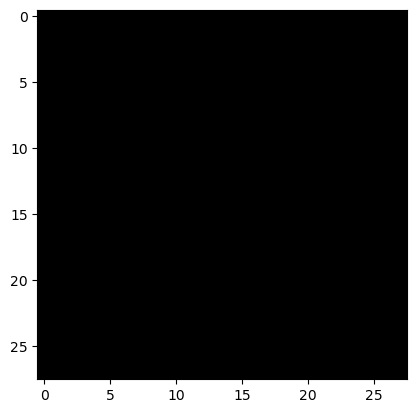

In [64]:
import matplotlib.pyplot as plt
img = np.full( (28,28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28,28), 200, dtype=np.uint8) # 회색
img = np.zeros( (28,28), dtype=np.uint8) # 검정색
#plt.figure(figsize=(1,1))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [65]:
import numpy as np
np.empty( (3, 2) )

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기
※ n차원 배열 만들기
- np.random.random( tup ) : 0부터 1미만의 균등분포를 갖은 tup 사이즈 랜덤값

- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값

- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜덤값
---
※ 1차원 배열 만들기
- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)

- np.random.randn(n) : 표준정규분포(평균0, 표준편차가1인 정규분포)의 1차원 난수 배열 발생(난수 n개)
---
※ 난수 1개 만들기
- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0, n-1)

- np.random.randint(from, to) : from부터 to미만의 정수 난수 1개발생 == random.randint(from,to-1)
                         == random.randiny(from,to-1)

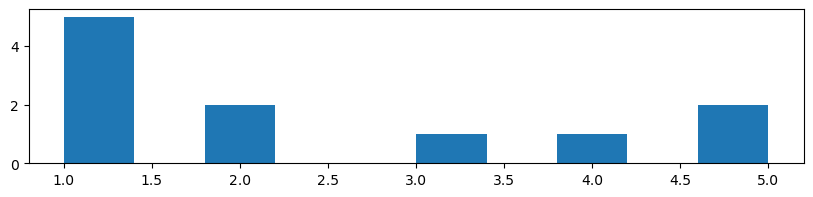

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = [1, 2, 3, 1, 1, 1, 2, 1, 4, 5, 5]
plt.hist(x, bins=10)
plt.show()

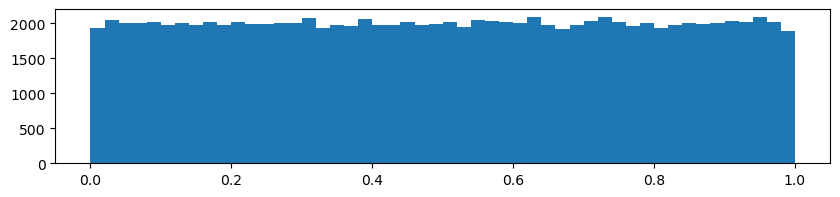

In [67]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
# x = np.random.random(1000000)
# x = np.random.uniform(1, 10, 10000000)
x = np.random.rand(100000)
plt.hist(x, bins=50)
plt.show()

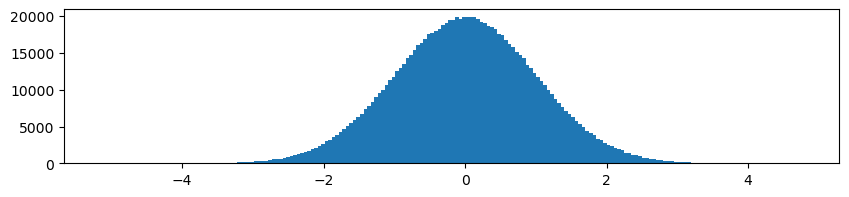

In [68]:
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000) # 정규분포
x = np.random.normal(0, 1, 1000000) # 표준정규분포
x = np.random.randn(1000000)# 표준정규분포
plt.hist(x, bins=200)
plt.show()

In [69]:
# 2차원 균등분포 난수 (0~1 미만 실수 난수) 배열
import numpy as np
# np.random.seed(3) # seed값을 맞추면 발생되는 난수가 동일. seed값을 초기화 하려면 커널 재시작
np.random.random ( (2, 5) ) # 2행 5열 짜리 2차원 난수 배열

array([[0.86640347, 0.67548392, 0.56373682, 0.97937498, 0.33946139],
       [0.49455121, 0.67611826, 0.22963101, 0.11120352, 0.15126424]])

In [70]:
# 2차원 균등분포 난수 (-1~1 미만 실수 난수) 배열
np.random.uniform(-1, 1, (2, 5)) # 2행 5열 2차원 배열

array([[-0.7142065 ,  0.76068299,  0.45546914,  0.80314357,  0.60504557],
       [-0.63174958, -0.63343271, -0.35140706, -0.04670876, -0.03678868]])

In [71]:
# 2차원 정규분포 난수 (평균 3에 표준편차 1인 난수) 배열
np.random.normal(3, 1, (2,5) ) # 1행 5열 2차원 배열

array([[3.01308545, 3.03759127, 3.05561074, 3.20426806, 4.21006322],
       [3.1699112 , 4.16683543, 1.46771164, 2.70529518, 3.75209876]])

In [72]:
# 1차원 슌등분포 난수 배열
np.random.rand(3)
np.random.random(3)

array([0.51557593, 0.21548925, 0.47054438])

In [73]:
# 1차원 표준정규분포(평균 0, 표준편차1인 정규분포) 배열
np.random.randn(3)
np.random.normal(size=3)

array([-0.78791378,  0.79976584, -1.83345474])

## 2.4 연속된 값을 갖는 배열 만들기
- np.arange(from, to, by, dtype) : from 부터 to(to가 정수일 경우 to 미포함)앞까지 by 씩 건너뛴 값을 1차원 배열로 생성
- np.linspace(from, to, num) : from 부터 to(to포함)까지 num개 숫자긍릉 1차원 배열로 생성

In [74]:
np.arange(10, 30, 5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [75]:
np.arange(0, 2, 0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8])

In [76]:
np.linspace(0, 3, 20) # 0부터 3까지 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [77]:
np.linspace(0, 3, 20).reshape(4,5)

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [78]:
x = np.array([0, 1, 2, 3, 4, 5, 6])
# linspace : 특정 구간에 많은 수의 점을 생성할 때 유용
x = np.linspace(0, 30, 1000)
y = np.sin(x)

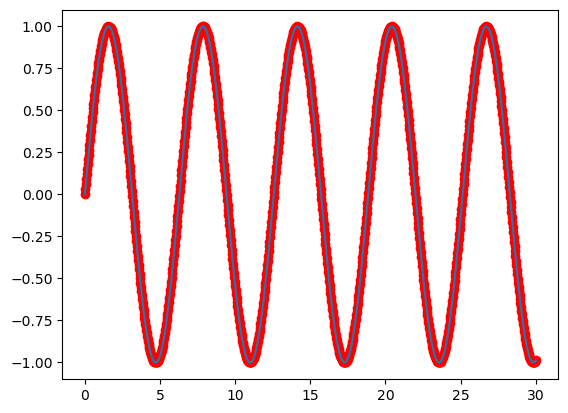

In [79]:
# import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
plt.scatter(x, y, c='r') # 빨산색 점그래프
plt.plot(x, y) # 선그래프
plt.show()

## 2.5 배열의 차원 변경
- reshape(행수, 열수) : - 차원 변경된 배열 return(-1 가능)
- resize( (행수,열수) ) : - 배열을 차원 변경(-1 불가)
- revel(), flatten() : 1차원으로 변경된 배열 return
- T : 전치행렬로 변환된 배열을 return
- transpose() : 전치행렬로 변환된배열을 return 

※ 실행결과가 출력되면 배열이 수정되지 않고, 실행결과가 없으면 배열이 수정됨

In [80]:
t = np.random.random( (2,5) )
print(t)
print(t*10)

[[0.44807009 0.25502146 0.82672431 0.90224625 0.96226689]
 [0.6538288  0.63535365 0.23190076 0.48959541 0.06825335]]
[[4.48070089 2.55021463 8.2672431  9.02246253 9.62266886]
 [6.53828796 6.35353646 2.31900764 4.89595406 0.68253351]]


In [81]:
# t * 10 요소별 연산 
# round(t*10) :  스칼라 값을 반올림
a = np.round(t*10)
a

array([[ 4.,  3.,  8.,  9., 10.],
       [ 7.,  6.,  2.,  5.,  1.]])

In [82]:
a = a.astype(np.int16) # astype()을 이욜한 요소별 타입 변환
a # 2행5열

array([[ 4,  3,  8,  9, 10],
       [ 7,  6,  2,  5,  1]], dtype=int16)

In [83]:
a.reshape(5,2)

array([[ 4,  3],
       [ 8,  9],
       [10,  7],
       [ 6,  2],
       [ 5,  1]], dtype=int16)

In [84]:
a.reshape(5,-1) # -1이 주어지면 해당 차원의 크기가 장동 계산 a의 item이 10이니까 5행으로 하면 2열로 자동 계산

array([[ 4,  3],
       [ 8,  9],
       [10,  7],
       [ 6,  2],
       [ 5,  1]], dtype=int16)

In [85]:
a = a.reshape(-1, 2)
a

array([[ 4,  3],
       [ 8,  9],
       [10,  7],
       [ 6,  2],
       [ 5,  1]], dtype=int16)

In [86]:
a.resize( (2, 5) ) # a를 바꿈
a.resize(2, 5)
a

array([[ 4,  3,  8,  9, 10],
       [ 7,  6,  2,  5,  1]], dtype=int16)

In [87]:
# a.resize(-1)  resize 함수에는 -1 불가

In [88]:
a.ravel()

array([ 4,  3,  8,  9, 10,  7,  6,  2,  5,  1], dtype=int16)

In [89]:
a.flatten()

array([ 4,  3,  8,  9, 10,  7,  6,  2,  5,  1], dtype=int16)

In [90]:
a

array([[ 4,  3,  8,  9, 10],
       [ 7,  6,  2,  5,  1]], dtype=int16)

In [91]:
a.T # a의 전체행렬(행과 열을 뒤바꾼 행렬 ex.0행 1열은 -> 1행 0열)

array([[ 4,  7],
       [ 3,  6],
       [ 8,  2],
       [ 9,  5],
       [10,  1]], dtype=int16)

In [92]:
a.transpose() # a의 전치행렬

array([[ 4,  7],
       [ 3,  6],
       [ 8,  2],
       [ 9,  5],
       [10,  1]], dtype=int16)

In [93]:
a

array([[ 4,  3,  8,  9, 10],
       [ 7,  6,  2,  5,  1]], dtype=int16)

## 2.6 배열 인쇄

In [94]:
print(np.arange(1001)) # item 갯수가 1000개 까지만 나옴. 배열이 너무 큼면 안 나옴

[   0    1    2 ...  998  999 1000]


In [95]:
print(np.arange(10000).reshape(100,100))

[[   0    1    2 ...   97   98   99]
 [ 100  101  102 ...  197  198  199]
 [ 200  201  202 ...  297  298  299]
 ...
 [9700 9701 9702 ... 9797 9798 9799]
 [9800 9801 9802 ... 9897 9898 9899]
 [9900 9901 9902 ... 9997 9998 9999]]


In [96]:
np.get_printoptions()['threshold'] # 출력되는 limit

1000

In [97]:
# 배열이 넘 커서 인쇄할 수 없는 경우 자동으로 건너뛰고 모서리 부분만 출력
# 넘파이의 인쇄 옵션 변경 (인쇄할 사이즈 조정)
np.set_printoptions(threshold=10000) # 배열 10000개까지 출력하도록 옵션 셋팅
np.set_printoptions(threshold=np.inf) # np.inf : 무한대
import sys
np.set_printoptions(threshold=sys.maxsize)

In [98]:
sys.maxsize

9223372036854775807

In [99]:
print(np.arange(10000).reshape(100,100))

[[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
    14   15   16   17   18   19   20   21   22   23   24   25   26   27
    28   29   30   31   32   33   34   35   36   37   38   39   40   41
    42   43   44   45   46   47   48   49   50   51   52   53   54   55
    56   57   58   59   60   61   62   63   64   65   66   67   68   69
    70   71   72   73   74   75   76   77   78   79   80   81   82   83
    84   85   86   87   88   89   90   91   92   93   94   95   96   97
    98   99]
 [ 100  101  102  103  104  105  106  107  108  109  110  111  112  113
   114  115  116  117  118  119  120  121  122  123  124  125  126  127
   128  129  130  131  132  133  134  135  136  137  138  139  140  141
   142  143  144  145  146  147  148  149  150  151  152  153  154  155
   156  157  158  159  160  161  162  163  164  165  166  167  168  169
   170  171  172  173  174  175  176  177  178  179  180  181  182  183
   184  185  186  187  188  189  190  191  192  193

In [100]:
# 커널을 재시작하거나
import numpy as np
np.set_printoptions(threshold=1000)
print(np.arange(10000).reshape(100,100))

[[   0    1    2 ...   97   98   99]
 [ 100  101  102 ...  197  198  199]
 [ 200  201  202 ...  297  298  299]
 ...
 [9700 9701 9702 ... 9797 9798 9799]
 [9800 9801 9802 ... 9897 9898 9899]
 [9900 9901 9902 ... 9997 9998 9999]]


## 2.7 기본 연산 동작
### 1) 배열의 요소별 연산

In [101]:
a = np.array([10, 20, 30, 40], dtype=np.int8)
b = np.arange(4) # np.int32
print(a) # 배열을 print에 넣으면 array와 ,(콤마)가 안나옴
print(b)
print(a.dtype, b.dtype)

[10 20 30 40]
[0 1 2 3]
int8 int32


In [102]:
c = a+b # 요소별 +연산 (dtype은 큰거로, 정수와 싨 연산은 실수오)
print(c)
print(c.dtype)

[10 21 32 43]
int32


In [103]:
a * 2

array([20, 40, 60, 80], dtype=int8)

In [104]:
a * b # 요소별 연산시 dtype이 큰 쪽인 int32

array([  0,  20,  60, 120])

In [105]:
a ** b

array([    1,    20,   900, 64000], dtype=int32)

In [106]:
a < 40

array([ True,  True,  True, False])

In [107]:
print(a[ [0,1,2,3] ]) # index를 list로
print(a[ [True,  True,  True, False] ]) # boolean index
print(a [ [0, 1, 2] ])

[10 20 30 40]
[10 20 30]
[10 20 30]


In [108]:
# a배열에서 40미만인 데이터만 추출하려면 boolean index 사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [109]:
# a배열에서 40미만인 데이터의 index
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2) 행렬의곱(@, dot함수) cf. *(요소별 곱)
- 2차원 배열은 행렬로 취급
- pdf 18page

In [110]:
A = np.array([[1, 1],
              [0, 1]])
B = np.array([[2, 0],
              [3, 4]])
A ,B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [111]:
print('요소별 곱 A*B =', A*B, sep="\n")
print('행렬 곱 A@B =', A@B, sep="\n")
print("행렬곱 A.dot(B) =", A.dot(B), sep="\n")

요소별 곱 A*B =
[[2 0]
 [0 4]]
행렬 곱 A@B =
[[5 4]
 [3 4]]
행렬곱 A.dot(B) =
[[5 4]
 [3 4]]


In [112]:
A = np.array([[1, 2,],
              [3, 4,]])
B = np.array([[-1, -1],
              [1, 1]])
print(A@B, B@A, sep="\n")

[[1 1]
 [1 1]]
[[-4 -6]
 [ 4  6]]


In [113]:
A = np.array([[1, 2,],
              [3, 4,]])
B = np.array([[6],
              [7]])
print(A@B) # 2x2 @ 2x1 => 2x1
# m행 r열 @ r행 n열 =? m행 n열
# b@a 에러 <= 2x1 @ 2x2

[[20]
 [46]]


In [114]:
A = np.array([[1, 2, 3],
              [3, 4, 1]])
B = np.array([[0, 0],
              [1, 1],
              [-1, 2]])
print(A@B, B@A, sep="\n")

[[-1  8]
 [ 3  6]]
[[ 0  0  0]
 [ 4  6  4]
 [ 5  6 -1]]


In [115]:
# a@단위행렬 == 단위행렬@a ; 단위 행렬에서는 행렬곱의 교환법칙이 성립
A = np.array([[1, 0],
              [0, 1]]) # 2행 2열짜리 단위행렬
B = np.array([[2, 0],
              [3, 4]])
print(A@B, B@A, sep="\n")

[[2 0]
 [3 4]]
[[2 0]
 [3 4]]


In [116]:
# 2행 2열 단위행렬
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 3) 복합 대입 연산자 사용(+=,-=, ...)
- 배열에서는 a += b는 a=a+b와 다소 다르게 작동

In [182]:
a = np.ones( (2, 3), dtype='int8') # int8 범위 -128~127
b = np.random.random( (2,3) ) # float 64
print(a , b, sep="\n")

[[1 1 1]
 [1 1 1]]
[[0.93697189 0.93428485 0.26583469]
 [0.80749548 0.60522633 0.6861281 ]]


In [183]:
a += 5 # a = a+5
a

array([[6, 6, 6],
       [6, 6, 6]], dtype=int8)

In [184]:
a += 255 # 공간이 부족하면 a에 오류
a

array([[5, 5, 5],
       [5, 5, 5]], dtype=int8)

In [185]:
a = a+255 # a+255를 요소별로 계산하여 새로운 a배열을 생성하여 할당
a

array([[260, 260, 260],
       [260, 260, 260]], dtype=int16)

In [186]:
b += a # b+a를 기존의 b에 넣는다 
b

array([[260.93697189, 260.93428485, 260.26583469],
       [260.80749548, 260.60522633, 260.6861281 ]])

In [187]:
a += b # a+b(float64)를 기존의 a에 넣는다

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [188]:
# 스칼라 데이터에서는 문제되지 않음
x = 5
y = 5.7
x += y
x

10.7

### 4) 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준편차)

In [249]:
a = np.array([[2, 2, 2, 3],
              [4, 3, 2, 1]])

In [190]:
print('전체 합 :', a.sum(), np.sum(a))
print('전체 최소값 :', a.min(), np.min(a))
print('전체 최댓값 :', a.max(), np.max(a))
print('전체 평균 :', a.mean(), np.mean(a))
print('전체 분산 :', a.var(), np.var(a))
print('전체 표준편차 :', a.std(), np.std(a))

전체 합 : 19 19
전체 최소값 : 1 1
전체 최댓값 : 4 4
전체 평균 : 2.375 2.375
전체 분산 : 0.734375 0.734375
전체 표준편차 : 0.8569568250501305 0.8569568250501305


In [191]:
# 분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var()) # math.sqrt(스칼라값)

0.8569568250501305

### 5) 배열 축별 집계 
- 축별 sum,min,max,mean,var,std
    * 1차원일때 axis0=열
    * 2차원일때 axis0=행, axis1=열
    * 3차원일때 axis0=면, axis1=행, axis2=열    

In [192]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [193]:
# axis=1(1축)들의 합 : 행을 고정하고 1축(열들) 의 합
print('a의 행별 합 :', a.sum(axis=1), np.sum(a, axis=1))

a의 행별 합 : [ 9 10] [ 9 10]


In [194]:
# axis=1을 고정하고 0축(행들)의 합
print('a의 열별 합 :', a.sum(axis=0), np.sum(a, axis=0))

a의 열별 합 : [6 5 4 4] [6 5 4 4]


In [195]:
# 3차원 배열의 집계
b = np.arange(24).reshape(2, 3, 4) # 2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [196]:
b[0, 1, 2]

6

In [197]:
b.sum(), np.sum(b), b.min(), np.min(b) # 배열 전체 요소에 대한 집계

(276, 276, 0, 0)

In [198]:
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [199]:
b.sum(axis=0) # 행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [200]:
b.sum(axis=1) # 면과 열은 고정하고 행이 합 0,0,0 + 0,1,0 + 0,2,0

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [201]:
b.sum(axis=2) # 면과 행은 고정하고 열들의 합

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근 / math.sqrt(스칼라 변수)
- np.add(A ,B, C) : C = np.add(A, B)와 동일 / C=A+B와 동일 의미
- np.multiply(A, B, C) : C = np.multiply(A, B) / C = A*B와 동일 의미
- np.subtract(A, B, C) : C = np.subtract(A, B) / C = A-B와 동일 의미

In [214]:
a = np.array([1, 4])
b = np.array([3, 4])
c = np.array(2)
a, b, c

(array([1, 4]), array([3, 4]), array(2))

In [215]:
# math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [217]:
np.add(a, b, c) # c=np.add(a, b), c= a + b
c = a + b
c

array([4, 8])

## 2.9 브로드케스팅
- 서로 다른 크기의 배열 간 연산을 수행할 수 있도록 해주는 강력한 기능

In [222]:
# 1차원 배열인 경우 (pdf 36p.)
a = np.array([1, 2, 3])
b = np.array([2])
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [223]:
a = np.array([1, 2, 3])
b = 2
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [224]:
a*b

array([2, 4, 6])

In [225]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
              [10,10,10],
              [20,20,20],
              [30,30,30]]) # 4x3 배열
b = np.array([[1,2,3]]) # 3열짜리 배열
a + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [227]:
a = np.array([[0,0,0],
              [10,10,10],
              [20,20,20],
              [30,30,30]]) # 4x3 배열
b = np.array([[0],
              [1],
              [2],
              [3]]) # 4행 1열짜리 배열
# 브로드케스팅되서 아래와 같이 연산
# b = np.array([[0,0,0],
#               [1,1,1],
#               [2,2,2],
#               [3,3,3]]) # 4행 1열짜리 배열
a + b

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [229]:
# 브로드케스팅이을 할수 없는 예(pdf 28p.)
a = np.array([0, 10, 20, 30])
b = np.array([1, 2, 3])
a + b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [230]:
a

array([ 0, 10, 20, 30])

In [242]:
# np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가 => 2차원
A = a[:, np.newaxis]
# A = a.reshape(4, 1)
# A = np.expand_dims(a, axis=1)
A

array([[ 0],
       [10],
       [20],
       [30]])

In [243]:
# a와 b의 모든 쌍 조합에 계산하고 싶을 떄 : 브로드케스팅 특성 이용, np.ix_함수 이용
A + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [245]:
ax, bx = np.ix_(a, b) # N개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절. 배열 합치기/분리하기
- 슬라이싱
- 두배열을 합치는 함수
- r_, c_
- 하나의 배열을 여러개 작은 배열로 분리하는 함수
## 3.1 다차원 배열 인덱싱과 슬라이싱

In [246]:
b = np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [247]:
b[2, 1]

9

In [249]:
# 모든 행의 마지막 열 앞까지(종속변수를 제외하는 용도)
b[:,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [257]:
b[..., :-1] # 모든 행의 경우, 선행축은 생략 불가능 ex. b[, :-1] 에러

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [258]:
# 0~2행까지 모든 열 (모든 열의 경우, 생략가능 == 모든 열의 경우, 후행축은 생략 가능)
b[0:3,:]
b[0:3, ...]
b[0:3]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 3.2 두 배열을 쌓아 합치는 함수
- vstack ( tup ) : 아래로 추가하는 방식
- hstack ( tup ) : 옆으로 추가하는 방식
- dstack ( tup ) : 마지막 축(열)을 쌓아 합침(차원 증가)

In [262]:
c = np.array([1, 2, 3])
d = np.array([4, 5, 6])
v = np.vstack( (c, d) )
print('vstack으로 아래로 합치기 : ', v, v.shape, sep='\n')
h = np.hstack( (c, d) )
print('hstack으로 옆으로 합치기 : ', h, h.shape, sep='\n')
d = np.dstack( (c, d) )
print('dstack으로 depth로 합치기 : ', d, d.shape, sep='\n')

vstack으로 아래로 합치기 : 
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기 : 
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기 : 
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [264]:
c = np.arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [265]:
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [266]:
# 수직으로 합치기
np.vstack( (a, b) )

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [267]:
np.concatenate( (a, b), axis=0) # axis=0이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [268]:
#수평으로 합치기
np.hstack( (a, b) )

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [269]:
np.concatenate( (a, b), axis=1)

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [272]:
np.dstack( (a, b) )

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

- colum_stack(tup) : 1차원 배열을 2차원 배열의 열단위 합침
- row_stack(tup) : 행단위로 합칩 == vstack()

In [273]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])
np.column_stack( (a, b, c) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [277]:
np.hstack( (a[:, np.newaxis], b[:, np.newaxis], c[:, np.newaxis]) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [278]:
np.row_stack( (a, b, c) )

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [279]:
np.vstack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack(tup, axis=n) : axis속성에 따라 배열을 합침. axis는 음수차원 0행/1열/-1

In [281]:
c = np.arange(24).reshape(2, 3, 4)
a,b = c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [283]:
np.stack( (a,b), axis=0) # 2차원 배열끼리 stack하면 3차원으로 axis=0 면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [285]:
np.stack( (a,b), axis=1) # axis=1 행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [287]:
np.stack( (a,b), axis=2 ) # a의 행과 b의 행이 열로 합치기

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_, c_
- 나열 객체

In [288]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])

In [289]:
np.r_[a, b, c] # 한행

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [291]:
np.r_[[a], [b], [c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [292]:
np.c_[a, b, c] # 컬럼 단이로 쌓아줌(c_ colum_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [294]:
np.column_stack( (a,b,c) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수
- vsplit( ary, 정수나 벡터 ) : 첫번째 축(axis0 - 2차원의 경우 가로축)을 따라 분할
- hsplit( ary, 정수나 벡터 ) : 두번째 축(axis1 - 2차원의 경우 세로축)을 따라 분할
- split( ary, 정수나 벡터, axis )
---
- array_split( ary, 정수나 벡터, axis )
- **split()과 차이점은 나눠지지 않은 정수로도 사용 가능**

In [297]:
a= np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [298]:
a_spilt = np.vsplit(a, 3) # 가로축(axis0축)을 따라 3개로 분할
a_spilt

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [300]:
a_spilt = np.vsplit(a, [2]) # 가로축(axis0축)을 따라 2번째 index앞에서 분할
a_spilt

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [305]:
np.hsplit(a, 2) # a를 2개로 세로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [306]:
np.hsplit(a, [3]) # a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [308]:
np.split(a, 3, axis=0) # 0축으로 분리. 2차원에서의 vsplit(a, 3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [309]:
np.split(a, 2, axis=1) # 1축으로 분리. 2차원에서의 hsplit(a, 2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [311]:
# np.split(a, 3, axis=1)
np.array_split(a, 3, axis=1) # 나눠지지 않는 정수 갯수를 알아서 나눠

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [313]:
np.split(a, [1, 2], axis=1) # 1번째 index, 2번째 index열을 기준으로 나눠

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4절. 복사와 뷰
## 4.1 할당

In [183]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b 데이터 :', a, b)

a와 b주소 : 2361679282704 2361679282704
수정 후 a와 b주소 : 2361679282704 2361679285552
수정 후 a와 b 데이터 : 10 99


In [184]:
# 배열
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [185]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 2361833552368)

In [186]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 2361833552368)

In [187]:
a is b

True

In [188]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [189]:
np.all(a==b) # np.all() array배열 안의 모든 값이 True인지 여부

True

In [190]:
b.shape = (3, 4)

In [191]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 2361833552368)

In [192]:
a.shape

(3, 4)

In [193]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2(View) : 얕은 복사

In [194]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [195]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [196]:
id(a), id(c)

(2361873040656, 2361873039600)

In [197]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [198]:
np.all(a==c)

True

In [199]:
a is c

False

In [200]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [201]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [202]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [203]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [204]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [205]:
X = a[:, :-1]
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [206]:
X[0:2, -1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [207]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [208]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [209]:
#X = a[:, :-1] # 얕은 복사(view생성)
X = a[:, :-1].copy() # 깊은 복사
# X = np.array(a[:, :-1], copy=True) # 깊은 복사

In [210]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

In [211]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

# 5절. 고급인덱싱
## 5.1 인덱스 배열로 인덱싱

In [315]:
a =np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [316]:
a[[0, 5, 9]]

array([ 0, 25, 81])

In [317]:
a[ [0, 1, 1, 5] ]

array([ 0,  1,  1, 25])

In [320]:
# 인덱싱하기 위한 값을 1차원 배열
idx_ary = np.array([0, 5, 5, 8])
a[idx_ary] # 결과는 인덱싱 배열의 (4열짜리 1차원 배열)의 형태로 따라감

array([ 0, 25, 25, 64])

In [321]:
# 인덱싱하기 위한 값을 2차원 배열
idx_ary = np.array([[0, 5],
                    [5, 8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [322]:
# 인덱스 배열을 이용한 a수정
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [323]:
a[idx_ary] += 9 # 0번째, 5번째, 8번째. 복합대입연산자가 5번째는 한번만 적용
a

array([  0,   1,   4,   9,  16,   0,  36,  49,   0,  81, 100, 121])

## 5.2 argmax : 최대값이 있는 인덱스

In [325]:
data = np.sin(np.arange(20).reshape(5, 4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [327]:
# 각 열별 큰 값이 있는 index 행수
ind = data.argmax(axis=0) # 0행,1행,2행,3행 중 가장 큰값이 있는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [328]:
# 0열에서 제일큰 행값, 1열에서 제일 큰 행값
data[ind[0], 0], data[ind[1], 1]

(0.9893582466233818, 0.8414709848078965)

In [330]:
data_col_max = data[ind, range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [331]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [334]:
# 두 배열이 같은 여부
np.all(data_col_max == data.max(axis=0))

True

## 5.3 논리 배열을 이용한 인덱싱
- boolean index

In [335]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [336]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [340]:
a[a%2==0] # 배열에서 원하는 조건의 item만 추출

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [339]:
a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [342]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6절. 선형대수
- 2차원 배열을 행렬
    * 행렬곱 : @, np.dot()
    * 역행렬 : 어떤 행렬과 역행렬을 행렬곱하면 결과가 단위행렬 # np.linalg.
    * 전치행렬 : X.T, X.transpse()
    * 단위행렬 : np.eye(n) n행n열 단위행렬

<img src ="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F444IE%2FbtqYKaRk1gS%2FAAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DyVKMv7SY28sGjG4YykrL3KzDzYM%253D"
    width="400"
     style="float:left">

In [3]:
import numpy as np
a = np.array([[1, 2],
              [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [4]:
# a의 역행렬
1 / (4-6) * np.array([[4, -2],
                      [-3, 1]])

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [5]:
# a의 역행렬 : a의 역행렬 @ a == a @ a의 역행렬 == 단위행렬
np.linalg.inv(a)

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [6]:
a @ np.linalg.inv(a), np.linalg.inv(a) @ a

(array([[1.00000000e+00, 1.11022302e-16],
        [0.00000000e+00, 1.00000000e+00]]),
 array([[ 1.00000000e+00,  4.44089210e-16],
        [-5.55111512e-17,  1.00000000e+00]]))

In [7]:
np.eye(2)

array([[1., 0.],
       [0., 1.]])

In [8]:
a @ np.eye(2)

array([[1., 2.],
       [3., 4.]])

## 6.1 단별량 회귀분석(설형 연립방정식) : 독립변수 1, 데이터 2

In [20]:
import numpy as np
x = np.array([2, 4]) # 독립변수(입력데이터)
y = np.array([40,60]) # 종속변수(타겟변수)
Y = y.reshape(-1, 1)
Y = y[:, np.newaxis]
Y = np.expand_dims(y, axis=1)
Y = y[:, None]
X = np.column_stack( (x, np.ones(len(x)) ) )
X

array([[2., 1.],
       [4., 1.]])

In [21]:
#              X @ wb = Y
#   X의역행렬 @ X @ wb = X의역행렬 @ Y
# (X의역행렬 @ X) @ wb = X의역행렬 @ Y
#        단위행렬 @ wb = X의역행렬 @ Y
#  wb = X의역행렬 @ Y
wb = np.linalg.inv(X) @ Y
wb

array([[10.],
       [20.]])

In [22]:
wb[0], wb[1] # wight, bias

(array([10.]), array([20.]))

In [36]:
x_ = np.linspace(0, 10, 300)
h = wb[0]*x_ + wb[1] # 예측값
# h = np.add(np.multiply(wb[0], x_), wb[1]) # 데이터가 많고,  식이 복잡할경우 범용함수 사용 추천

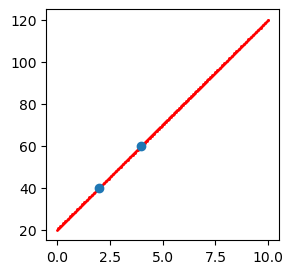

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3)) # 현재 셀의 그래프 사이즈 조정
# plt.rcPrams['figure.figsize']
plt.scatter(x_, h, c='r',s=1)
plt.scatter(x, y)
plt.show()

In [41]:
np.linalg.solve(X, Y) # X가 정방행렬일 경우

array([[10.],
       [20.]])

## 6.2 단별량 회귀분석(설형 연립방정식) : 독립변수 1, 데이터 N개

In [43]:
a = np.array([[2, 1], [3, 1], [4, 1], [5, 1]])
a # 정방행렬이 아님

array([[2, 1],
       [3, 1],
       [4, 1],
       [5, 1]])

In [45]:
# 역행렬(정방행렬일 때만 역행렬 가능)
# np.linalg.inv(a)

In [47]:
a.T # 전치행렬

array([[2, 3, 4, 5],
       [1, 1, 1, 1]])

In [48]:
a.T @ a # a가 정방행렬이 아니면 전치행렬을 곱하여 정방행렬을 만듦

array([[54, 14],
       [14,  4]])

In [52]:
np.linalg.inv(a.T @ a) # a.T @ a의 역행렬

array([[ 0.2, -0.7],
       [-0.7,  2.7]])

In [53]:
np.linalg.inv(a.T @ a) @ a.T @ a

array([[ 1.00000000e+00,  9.43689571e-16],
       [-2.66453526e-15,  1.00000000e+00]])

In [61]:
x = np.array([32, 64, 96, 118, 126, 144, 152.5, 158]) # 독립변수(입력데이터)
y = np.array([18, 24, 61.5, 49, 52, 105, 130.3, 125]) # 종속변수(타겟데이터)
X = np.column_stack( (x, np.ones(8) ) )
X = np.c_[x, np.ones(len(x))]
X = np.dstack( (x, np.ones(len(x))) ).reshape(-1, 2)
print(X)
Y = y[:, np.newaxis]
Y = y[:, None]
Y = np.expand_dims(y, axis=1)
Y = y.reshape(-1, 1)
print(Y)

[[ 32.    1. ]
 [ 64.    1. ]
 [ 96.    1. ]
 [118.    1. ]
 [126.    1. ]
 [144.    1. ]
 [152.5   1. ]
 [158.    1. ]]
[[ 18. ]
 [ 24. ]
 [ 61.5]
 [ 49. ]
 [ 52. ]
 [105. ]
 [130.3]
 [125. ]]


In [62]:
#                           X @ wb = Y
#                   (X.T @ X) @ wb = X.T @ Y
# X.T @ X의 역행렬 @ (X.T @ X) @ wb = X.T @ X의 역행렬 @ X.T @ Y
# X.T @ X의 역행렬 @ (X.T @ X) @ wb = X.T @ X의 역행렬 @ X.T @ Y
#                               wb = X.T @ X의 역행렬 @ X.T @ Y

In [63]:
wb = np.linalg.inv(X.T@X) @ X.T @ Y
wb

array([[  0.87493126],
       [-26.79078617]])

In [64]:
h = wb[0]*x + wb[1] # 도출된 회귀식( y=w*x+b )으로 계사된 예측값

In [65]:
print('독립변수 : ', x)
print('실제값 : ', y)
print('예측값 : ', h)

독립변수 :  [ 32.   64.   96.  118.  126.  144.  152.5 158. ]
실제값 :  [ 18.   24.   61.5  49.   52.  105.  130.3 125. ]
예측값 :  [  1.20701424  29.20481464  57.20261504  76.45110282  83.45055292
  99.19931565 106.63623138 111.44835332]


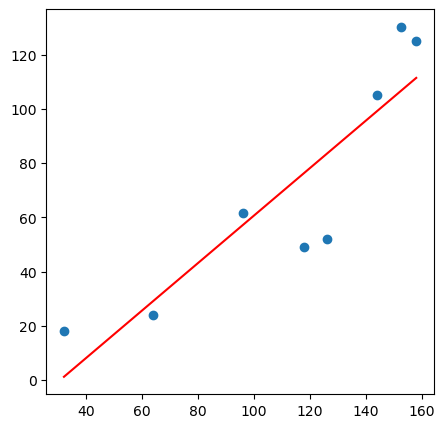

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
# plt.rcParams['figure.figsize'] = (5,5)
plt.scatter(x, y)
# plt.scatter(x, h, c='r') # 점그래프
plt.plot(x, h, c='r') # 선그래프

## 6.3 다변량 회귀분석(설형 연립방정식) : 독립변수 N개 , 데이터 N개

In [70]:
x1 = np.array([60,65,55])
x2 = np.array([5.5, 5.0, 6.0])
x3 = np.array([1, 0, 1])
y = np.array([66,74,78])
X = np.column_stack( (x1, x2, x3) )
X = np.c_[x1,x2,x3]
print(X)
Y = y.reshape(-1, 1) # y[:, np.newaxis]
print(Y)

[[60.   5.5  1. ]
 [65.   5.   0. ]
 [55.   6.   1. ]]
[[66]
 [74]
 [78]]


In [71]:
#               X @ w = Y
#        X의역행렬 @ X @ w = X의역행렬 @ Y
#    w = X의역행렬 @ Y    

In [72]:
W = np.linalg.inv(X) @ Y
W

array([[ -0.4],
       [ 20. ],
       [-20. ]])

In [73]:
# 80kg, 6.5ft, no(0)의 수명은?
80*W[0] + 6.5*W[1] + 0 *W[2]

array([98.])

# 7절. 연습문제
## 실습형

In [10]:
from sklearn import datasets # sklearn 패키지(머신러닝 및 전처리)안의 datasets모듈을 load
iris = datasets.load_iris()
print(type(iris))
iris_data = iris.data
iris_data

<class 'sklearn.utils._bunch.Bunch'>


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [11]:
print(iris.target) # 종속변수(타겟변수)
print(iris.target_names) # 종속변수가 뜻하는 종의 이름

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [12]:
# 인덱스 배열을 이용한 원 데이터의 종속변수
iris.target_names[iris.target][::50]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### 연습문제 실습형

In [13]:
iris.data.mean(axis=0)

array([5.84333333, 3.05733333, 3.758     , 1.19933333])

In [31]:
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [15]:
iris.data[:5,:-1]

array([[5.1, 3.5, 1.4],
       [4.9, 3. , 1.4],
       [4.7, 3.2, 1.3],
       [4.6, 3.1, 1.5],
       [5. , 3.6, 1.4]])

In [16]:
iris.data[:5,-1]

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [17]:
a = iris.data[:5,:-1]
b = iris.data[:5,-1]
np.c_[a, b]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [35]:
q = iris.data[:5]
q[q>q.mean(axis=0)]

array([5.1, 3.5, 4.9, 1.5, 5. , 3.6])

# 문제풀이형


In [20]:
# 1번문제 정답 : 1번
# 2번문제 정답 : 1번
# 3번문제 정답 : 1번
# 4번문제 정답 : 1번
# 5번문제 정답 : 1번
